# Country-of-citizenship polity dates

We extracted the **inception** and **dissolution** dates from Wikidata for every country of citizenship that appears in the `country_of_citizenship` table of `humans_clean.duckdb`.

This notebook reports:

1. The share of polities for which Wikidata exposes inception / dissolution / both.
2. The distribution of polity **lifespans** (years between earliest inception and latest dissolution), unweighted and weighted by the number of individuals attached to each polity.

Multi-valued Wikidata dates (separated by `|`) are flattened by taking the **earliest** inception and the **latest** dissolution, which gives the polity's overall span.

In [ ]:
import re
import duckdb
import numpy as np
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt

DB_PATH = "../data/humans_clean.duckdb"

FIGSIZE = (9.5, 5.5)
DPI = 120
COLOR_BAR = "#2171b5"
COLOR_ALT = "#b5542a"
COLOR_TEXT = "#444444"

mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

## Load the table

Columns of interest: `wikidata_id`, `name_en`, `count` (individuals attached), `inception`, `dissolved`. Both date columns may carry multiple `|`-separated ISO-8601 timestamps; BCE dates are prefixed with `-`.

In [ ]:
con = duckdb.connect(DB_PATH, read_only=True)

polities = con.execute("""
    SELECT wikidata_id,
           name_en,
           count        AS n_individuals,
           inception,
           dissolved
    FROM country_of_citizenship
""").pl()

print(f"polities: {polities.height:,}")
polities.head()

In [3]:
YEAR_RE = re.compile(r"^(-?\d{1,4})-\d{2}-\d{2}T")

def parse_years(cell: str | None) -> list[int]:
    if cell is None or cell == "":
        return []
    out = []
    for tok in cell.split("|"):
        m = YEAR_RE.match(tok.strip())
        if m:
            out.append(int(m.group(1)))
    return out

def earliest(cell):
    ys = parse_years(cell)
    return min(ys) if ys else None

def latest(cell):
    ys = parse_years(cell)
    return max(ys) if ys else None

polities = polities.with_columns([
    pl.col("inception").map_elements(earliest, return_dtype=pl.Int64).alias("inception_year"),
    pl.col("dissolved").map_elements(latest, return_dtype=pl.Int64).alias("dissolved_year"),
])

polities = polities.with_columns(
    (pl.col("dissolved_year") - pl.col("inception_year")).alias("lifespan_years")
)

polities.select([
    "name_en", "n_individuals", "inception_year", "dissolved_year", "lifespan_years"
]).head()

name_en,n_individuals,inception_year,dissolved_year,lifespan_years
str,i64,i64,i64,i64
"""Duchy of Legnica""",8,1248,1675,427
"""Maore sultanate""",2,1500,1841,341
"""Electorate of Mainz""",22,780,1803,1023
"""Marquisate of Bosco""",1,null,null,null
"""Later Jin (1616-1636)""",15,1616,1636,20


## Coverage

Share of polities (and share of *individual–polity attachments* — i.e. weighted by `count`) for which Wikidata supplies inception, dissolution, both, or either.

In [4]:
n = polities.height
tot_ind = int(polities["n_individuals"].sum())

def share(mask):
    sub = polities.filter(mask)
    return sub.height, int(sub["n_individuals"].sum())

rows = []
for label, mask in [
    ("inception",       pl.col("inception_year").is_not_null()),
    ("dissolved",       pl.col("dissolved_year").is_not_null()),
    ("both",            pl.col("inception_year").is_not_null() & pl.col("dissolved_year").is_not_null()),
    ("either",          pl.col("inception_year").is_not_null() | pl.col("dissolved_year").is_not_null()),
]:
    k, w = share(mask)
    rows.append({
        "field": label,
        "polities": k,
        "polities_pct": round(100 * k / n, 1),
        "weighted_individuals": w,
        "weighted_pct": round(100 * w / tot_ind, 1),
    })

coverage = pl.DataFrame(rows)
print(f"total polities: {n:,}    total individual–polity rows: {tot_ind:,}")
coverage

total polities: 4,572    total individual–polity rows: 6,052,473


field,polities,polities_pct,weighted_individuals,weighted_pct
str,i64,f64,i64,f64
"""inception""",2779,60.8,6028684,99.6
"""dissolved""",2196,48.0,1113043,18.4
"""both""",2111,46.2,1101094,18.2
"""either""",2864,62.6,6040633,99.8


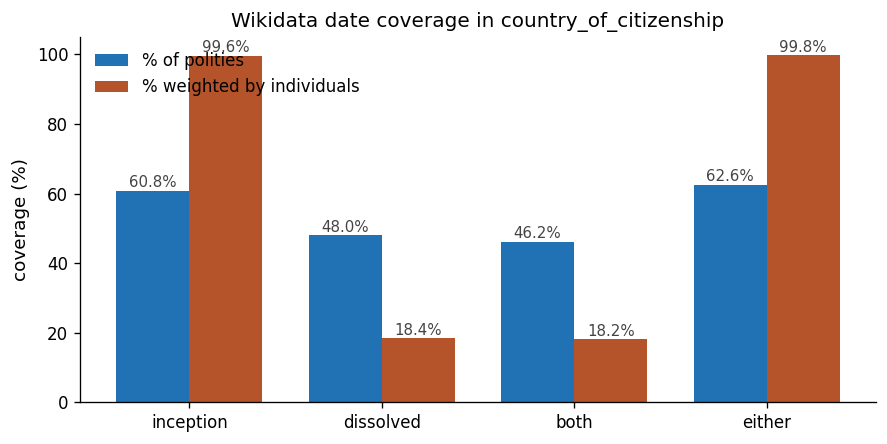

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
labels = coverage["field"].to_list()
x = np.arange(len(labels))
w = 0.38

ax.bar(x - w/2, coverage["polities_pct"].to_list(),
       width=w, color=COLOR_BAR, label="% of polities")
ax.bar(x + w/2, coverage["weighted_pct"].to_list(),
       width=w, color=COLOR_ALT, label="% weighted by individuals")

for i, (a, b) in enumerate(zip(coverage["polities_pct"].to_list(),
                                coverage["weighted_pct"].to_list())):
    ax.text(i - w/2, a + 1, f"{a:.1f}%", ha="center", fontsize=9, color=COLOR_TEXT)
    ax.text(i + w/2, b + 1, f"{b:.1f}%", ha="center", fontsize=9, color=COLOR_TEXT)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 105)
ax.set_ylabel("coverage (%)")
ax.set_title("Wikidata date coverage in country_of_citizenship")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Distribution of polity lifespans

Lifespan = `latest dissolved year − earliest inception year`. Restricted to polities with **both** dates available. We show two views:

- **Unweighted** — one observation per polity.
- **Weighted by individuals** — each polity contributes its `count` field (so a polity with 10 000 individuals carries 10 000× the mass of one with 1).

In [6]:
ls = polities.filter(pl.col("lifespan_years").is_not_null())
vals = ls["lifespan_years"].to_numpy().astype(float)
wts  = ls["n_individuals"].to_numpy().astype(float)

def pct(v, q, w=None):
    if w is None:
        return float(np.percentile(v, q))
    order = np.argsort(v)
    v_s, w_s = v[order], w[order]
    cum = np.cumsum(w_s) / w_s.sum()
    return float(v_s[np.searchsorted(cum, q / 100.0)])

print(f"polities with both dates: {ls.height:,}  ({100*ls.height/polities.height:.1f}% of all)")
print()
print("unweighted lifespan (years)")
print(f"  median {np.median(vals):>6.0f}   mean {vals.mean():>6.0f}   p10 {pct(vals,10):>4.0f}   p90 {pct(vals,90):>5.0f}   max {vals.max():>5.0f}")
print("weighted by n_individuals")
print(f"  median {pct(vals,50,wts):>6.0f}                    p10 {pct(vals,10,wts):>4.0f}   p90 {pct(vals,90,wts):>5.0f}")

polities with both dates: 2,111  (46.2% of all)

unweighted lifespan (years)
  median    131   mean    251   p10    4   p90   629   max  4810
weighted by n_individuals
  median    108                    p10   17   p90   319


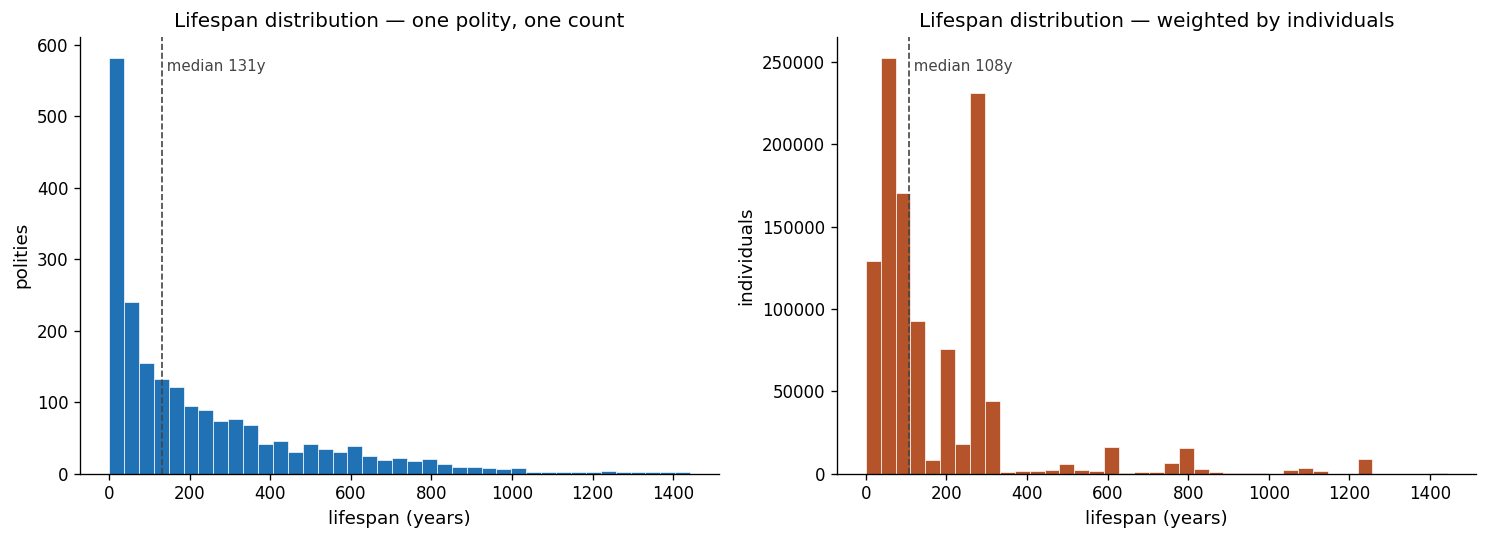

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=False)

bins = np.linspace(0, np.percentile(vals, 99), 40)

ax = axes[0]
ax.hist(vals, bins=bins, color=COLOR_BAR, edgecolor="white", linewidth=0.4)
ax.axvline(np.median(vals), color=COLOR_TEXT, lw=1, ls="--")
ax.text(np.median(vals), ax.get_ylim()[1]*0.95, f" median {np.median(vals):.0f}y",
        color=COLOR_TEXT, va="top", fontsize=9)
ax.set_title("Lifespan distribution — one polity, one count")
ax.set_xlabel("lifespan (years)")
ax.set_ylabel("polities")

ax = axes[1]
ax.hist(vals, bins=bins, weights=wts, color=COLOR_ALT, edgecolor="white", linewidth=0.4)
med_w = pct(vals, 50, wts)
ax.axvline(med_w, color=COLOR_TEXT, lw=1, ls="--")
ax.text(med_w, ax.get_ylim()[1]*0.95, f" median {med_w:.0f}y",
        color=COLOR_TEXT, va="top", fontsize=9)
ax.set_title("Lifespan distribution — weighted by individuals")
ax.set_xlabel("lifespan (years)")
ax.set_ylabel("individuals")

plt.tight_layout()
plt.show()

## Longest- and shortest-lived polities (top by individual count)

In [8]:
view = (
    ls.select(["name_en", "n_individuals", "inception_year", "dissolved_year", "lifespan_years"])
      .sort("n_individuals", descending=True)
      .head(20)
)
view

name_en,n_individuals,inception_year,dissolved_year,lifespan_years
str,i64,i64,i64,i64
"""Soviet Union""",173248,1922,1991,69
"""Ming dynasty""",123926,1368,1644,276
"""United Kingdom of Great Britai…",83281,1801,1927,126
"""Kingdom of Italy""",64823,476,493,17
"""Qing dynasty""",60716,1636,1912,276
…,…,…,…,…
"""Ottoman Empire""",16138,1299,1922,623
"""German Reich""",14491,1871,1949,78
"""Austria–Hungary""",12965,1867,1918,51


## Polity *age* weighted by individuals

For each polity we take the **most recent** inception date — so France counts from 1804, Germany from 1949, Spain from 1978 — i.e. the modern republic, not the medieval kingdom. Polity age is then:

- `dissolved_year − modern_inception` if the polity is dissolved,
- `2026 − modern_inception` otherwise.

We weight by the number of individuals attached to each polity to answer: *what share of people in the dataset belong to polities younger than X years?*

In [9]:
NOW = 2026

polities = polities.with_columns(
    pl.col("inception").map_elements(latest, return_dtype=pl.Int64).alias("modern_inception")
)

polities = polities.with_columns(
    pl.when(pl.col("dissolved_year").is_not_null())
      .then(pl.col("dissolved_year") - pl.col("modern_inception"))
      .otherwise(NOW - pl.col("modern_inception"))
      .alias("polity_age")
)

aged = polities.filter(pl.col("polity_age").is_not_null())
ages = aged["polity_age"].to_numpy().astype(float)
wts  = aged["n_individuals"].to_numpy().astype(float)

order = np.argsort(ages)
a_s, w_s = ages[order], wts[order]
cum = np.cumsum(w_s) / w_s.sum()

def w_pct(q):
    return float(a_s[np.searchsorted(cum, q / 100.0)])

print(f"polities with modern inception: {aged.height:,}  ({100*aged.height/polities.height:.1f}%)")
print(f"individuals covered:            {int(w_s.sum()):,}  ({100*w_s.sum()/polities['n_individuals'].sum():.1f}%)")
print()
print("polity age, weighted by individuals (years)")
for q in (10, 25, 50, 75, 90):
    print(f"  p{q:>2}: {w_pct(q):>5.0f}")
print(f"  weighted mean: {np.average(ages, weights=wts):.0f}")
print()
print("share of individuals in polities younger than threshold")
for thr in (50, 100, 150, 200, 250, 500, 1000):
    share = w_s[a_s < thr].sum() / w_s.sum()
    print(f"  < {thr:>4} y : {100*share:5.1f}%")

polities with modern inception: 2,779  (60.8%)
individuals covered:            6,028,684  (99.6%)

polity age, weighted by individuals (years)
  p10:    48
  p25:    77
  p50:   109
  p75:   222
  p90:   276
  weighted mean: 199

share of individuals in polities younger than threshold
  <   50 y :  11.1%
  <  100 y :  43.5%
  <  150 y :  55.8%
  <  200 y :  62.6%
  <  250 y :  87.4%
  <  500 y :  92.5%
  < 1000 y :  95.5%


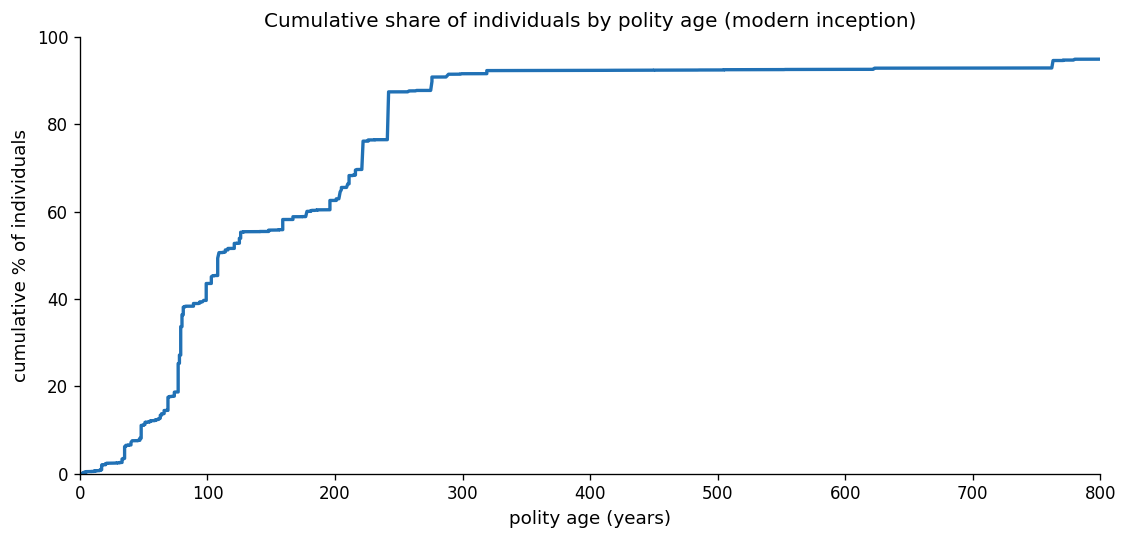

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
xs = np.concatenate([[0], a_s, [a_s.max()]])
ys = np.concatenate([[0], cum,  [1.0]])
ax.plot(xs, 100 * ys, color=COLOR_BAR, lw=2)

ax.set_xlim(0, 800)
ax.set_ylim(0, 100)
ax.set_xlabel("polity age (years)")
ax.set_ylabel("cumulative % of individuals")
ax.set_title("Cumulative share of individuals by polity age (modern inception)")
plt.tight_layout()
plt.show()